# **Trailers Analysis by Genre: Audio Focus**

**By : Kenza Charfi**

**Objective:**
Analyze and compare audio features of film trailers from three genres using Python: **Action**, **Horror**, and **Romance**.


# **Setup Environment**

In [ ]:
!pip install librosa matplotlib numpy IPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.5 MB/s eta 0:00:00


In [ ]:
!pip install yt_dlp moviepy librosa


  Using cached yt_dlp-2025.3.31-py3-none-any.whl.metadata (172 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.8 MB/s eta 0:00:00


In [ ]:
#Libraries
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd


# **Load and Preprocess Audio**

In [ ]:
import yt_dlp
from moviepy.editor import VideoFileClip
import librosa
import os

def download_youtube_audio(url, base_filename="trailer", duration=120):
    # Force yt_dlp to use webm and set final filename
    output_filename = f"{base_filename}.webm"

    ydl_opts = {
        'format': 'bestvideo+bestaudio',
        'outtmpl': output_filename
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    # Use correct filename (.webm instead of .mp4)
    clip = VideoFileClip(output_filename).subclip(0, duration)
    audio_path = output_filename.replace(".webm", ".wav")
    clip.audio.write_audiofile(audio_path, codec='pcm_s16le')

    return audio_path

# Trailer URLs
trailer_urls = {
    "Action": "https://www.youtube.com/watch?v=avz06PDqDbM",
    "Horror": "https://www.youtube.com/watch?v=k10ETZ41q5o",
    "Romance": "https://www.youtube.com/watch?v=BjJcYdEOI0k"
}

# Process all trailers
audio_data = {}
sr = 22050

for genre, url in trailer_urls.items():
    print(f"Downloading {genre} trailer...")
    audio_path = download_youtube_audio(url, base_filename=f"{genre.lower()}_trailer", duration=120)
    y, _ = librosa.load(audio_path, sr=sr)
    audio_data[genre] = y


[youtube] Extracting URL: https://www.youtube.com/watch?v=avz06PDqDbM
[youtube] avz06PDqDbM: Downloading webpage
[youtube] avz06PDqDbM: Downloading tv client config
[youtube] avz06PDqDbM: Downloading player 179bab65-main
[youtube] avz06PDqDbM: Downloading tv player API JSON
[youtube] avz06PDqDbM: Downloading ios player API JSON
[youtube] avz06PDqDbM: Downloading m3u8 information
[info] avz06PDqDbM: Downloading 1 format(s): 616+251
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 28
[download] Destination: action_trailer.f616.mp4
[download] 100% of   59.80MiB in 00:00:02 at 25.24MiB/s                
[download] Destination: action_trailer.f251.webm
[download] 100% of    2.15MiB in 00:00:00 at 14.71MiB/s  
[Merger] Merging formats into "action_trailer.webm"
Deleting original file action_trailer.f616.mp4 (pass -k to keep)
Deleting original file action_trailer.f251.webm (pass -k to keep)
MoviePy - Writing audio in action_trailer.wav


MoviePy - Done.
[youtube] Extracting URL: https://www.youtube.com/watch?v=k10ETZ41q5o
[youtube] k10ETZ41q5o: Downloading webpage
[youtube] k10ETZ41q5o: Downloading tv client config
[youtube] k10ETZ41q5o: Downloading player 236fc64d-main
[youtube] k10ETZ41q5o: Downloading tv player API JSON
[youtube] k10ETZ41q5o: Downloading ios player API JSON
[youtube] k10ETZ41q5o: Downloading m3u8 information
[info] k10ETZ41q5o: Downloading 1 format(s): 616+251
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 29
[download] Destination: horror_trailer.f616.mp4
[download] 100% of   30.26MiB in 00:00:02 at 10.48MiB/s                
[download] Destination: horror_trailer.f251.webm
[download] 100% of    2.02MiB in 00:00:00 at 7.99MiB/s   
[Merger] Merging formats into "horror_trailer.webm"
Deleting original file horror_trailer.f251.webm (pass -k to keep)
Deleting original file horror_trailer.f616.mp4 (pass -k to keep)
MoviePy - Writing audio in horror_trailer.wav


MoviePy - Done.
[youtube] Extracting URL: https://www.youtube.com/watch?v=BjJcYdEOI0k
[youtube] BjJcYdEOI0k: Downloading webpage
[youtube] BjJcYdEOI0k: Downloading tv client config
[youtube] BjJcYdEOI0k: Downloading player 64be519f-main
[youtube] BjJcYdEOI0k: Downloading tv player API JSON
[youtube] BjJcYdEOI0k: Downloading ios player API JSON
[youtube] BjJcYdEOI0k: Downloading m3u8 information
[info] BjJcYdEOI0k: Downloading 1 format(s): 399+251
[download] Destination: romance_trailer.f399.mp4
[download] 100% of   14.05MiB in 00:00:00 at 45.10MiB/s  
[download] Destination: romance_trailer.f251.webm
[download] 100% of    2.32MiB in 00:00:00 at 10.10MiB/s  
[Merger] Merging formats into "romance_trailer.webm"
Deleting original file romance_trailer.f399.mp4 (pass -k to keep)
Deleting original file romance_trailer.f251.webm (pass -k to keep)
MoviePy - Writing audio in romance_trailer.wav


MoviePy - Done.


# **Extract features:**

In [ ]:
def analyze_audio(y, sr):
    features = {}
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features["Tempo"] = float(tempo)
    features["RMS"] = np.mean(librosa.feature.rms(y=y))
    features["Spectral Centroid"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["Chroma"] = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
    return features

results = {}
for genre, y in audio_data.items():
    results[genre] = analyze_audio(y, sr)

import pandas as pd
df = pd.DataFrame(results).T.round(2)
df


  features["Tempo"] = float(tempo)



,Tempo,RMS,Spectral Centroid,Chroma
Action,143.55,0.11,1946.77,0.51
Horror,152.00,0.03,2319.64,0.47
Romance,112.35,0.04,2033.66,0.34


# **Visualization**
Tempo and Loudness by Genre

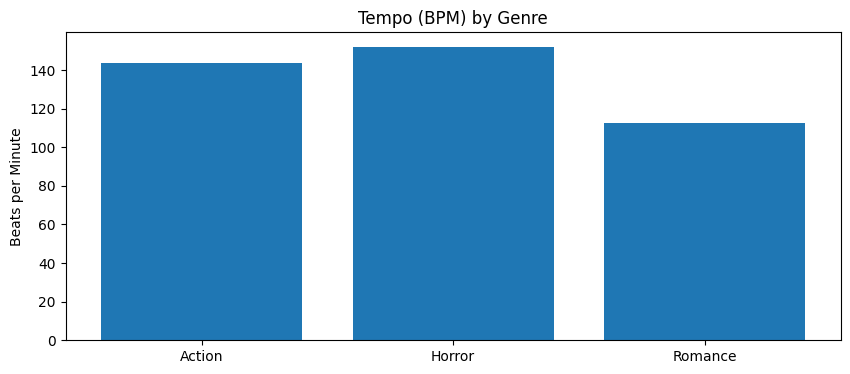

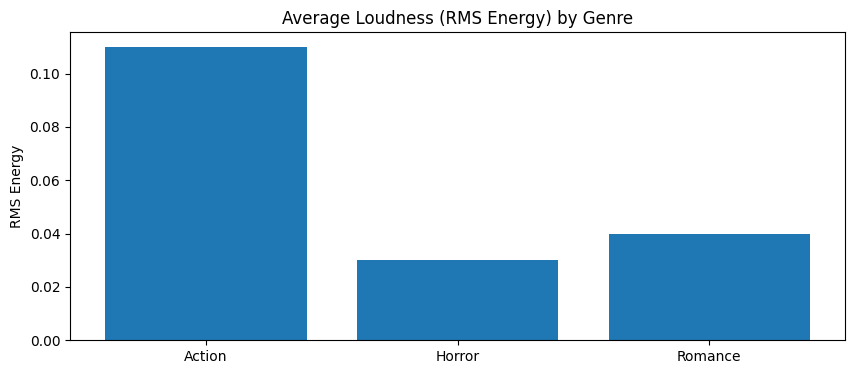

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(df.index, df["Tempo"])
plt.title("Tempo (BPM) by Genre")
plt.ylabel("Beats per Minute")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df.index, df["RMS"])
plt.title("Average Loudness (RMS Energy) by Genre")
plt.ylabel("RMS Energy")
plt.show()
